In [1]:
import os
os.chdir("..")

from utils.utils import notebook_line_magic
notebook_line_magic()

Line Magic Set


In [59]:
# os.listdir('/home/azm0269@auburn.edu/.cache/kagglehub/datasets/eduardo4jesus/stanford-cars-dataset/versions/1/cars/train')

In [14]:
import torch
import numpy as np
import torchvision
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader, Subset, RandomSampler

device = "cuda"

In [6]:
# import kagglehub
# Download latest version
# path = kagglehub.dataset_download(
#     "eduardo4jesus/stanford-cars-dataset")
# print("Path to dataset files:", path)

In [13]:
# class StanfordCars(Dataset):
#     def __init__(self, path, transform=None):
#         super(StanfordCars, self).__init__()
#         self.data = datasets.ImageFolder(path, transform)
#     def __getitem__(self, idx):
#         x, y = self.data[idx]
#     def __len__(self):
#         return len(self.data)

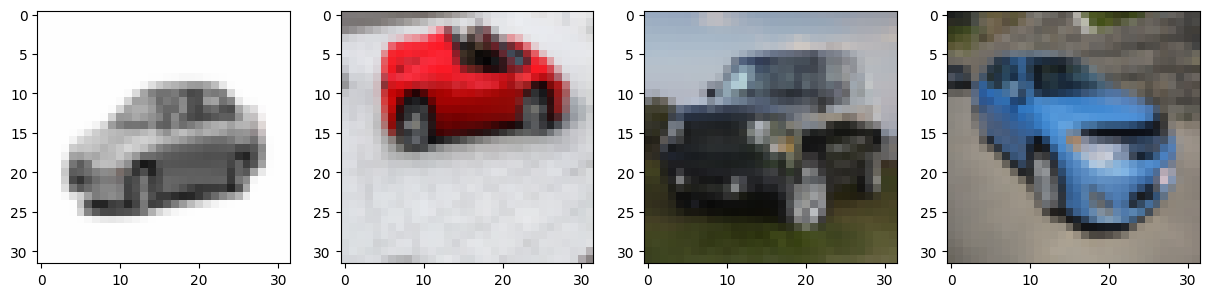

In [3]:
def show_images(dataset, num_samples=20, cols=4):
    """plot images
    """
    plt.figure(figsize=(15,15))
    for i, img in enumerate(dataset):
        if i == num_samples:
            break
        plt.subplot(int(num_samples/cols) + 1, cols, i +1)
        plt.imshow(img[0].permute(1,2,0))

data_transform = transforms.Compose([
    # Resize the images to 64x64
    transforms.Resize(size=(32, 32)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip, 0.5 = 50% chance
    # Turn the image into a torch.Tensor
    transforms.ToTensor() # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.0 
])

path = '/home/azm0269@auburn.edu/.cache/kagglehub/datasets/eduardo4jesus/stanford-cars-dataset/versions/1/cars/'
data = datasets.ImageFolder(
    root=path,
    transform=data_transform
)
train_dataloader = DataLoader(
    dataset=data, 
    batch_size=1, 
    num_workers=1, 
    shuffle=True
)

show_images(data, num_samples=4)

### Forward process - add noise (no model necessary here)

In [4]:
import torch.nn.functional as F

def linear_beta_schedule(timesteps, start=0.0002, end=0.02):
    return torch.linspace(start, end, timesteps)

def get_index_from_list(vals, t, x_shape):
    batch_size = t.shape[0]
    out = vals.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,)*(len(x_shape)-1))).to(t.device)

def forward_diffusion_sample(x_0, t, device="cpu"):
    noise=torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x_0.shape
    )
    return sqrt_alphas_cumprod_t.to(device)*x_0.to(device)\
        + sqrt_one_minus_alphas_cumprod_t.to(device)*noise.to(device), noise.to(device)
        
## define beta schedule
T = 300 #time steps
betas = linear_beta_schedule(timesteps=T)

# pre-compute terms for closed form solution
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1,0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0/alphas) #reciprocal alphas
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod) #this is used up in the forward_diffusion_sample function
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

In [7]:
# alphas_cumprod, alphas_cumprod_prev

In [17]:
IMG_SIZE = 64
BATCH_SIZE = 128

def load_transformed_dataset():
    ## load data
    from pathlib import Path
    data_path = Path("/home/azm0269@auburn.edu/.cache/kagglehub/datasets/eduardo4jesus/stanford-cars-dataset/versions/1/")
    image_path = data_path / "cars" 
    train_path = image_path / "train"
    test_path = image_path / "test"

    train_size = len(os.listdir(train_path))
    test_size = len(os.listdir(test_path))
    
    data_transforms = [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(), #scale data 0-1
        transforms.Lambda(lambda t: (t*2) - 1)
    ]
    data_transform = transforms.Compose(data_transforms)
    
    data = datasets.ImageFolder(
        root=image_path,
        transform=data_transform
    )
    train_dataset = Subset(data, np.arange(train_size)) #subset the original to get the training samples
    test_dataset = Subset(data, np.arange(test_size)) #subset the original to get the test samples
    return torch.utils.data.ConcatDataset([train_dataset, test_dataset]) # did all the shit above to just concat it again lmao
    
def show_image_tensor(image):
    reverse_transforms = transforms.Compose([
        transforms.Lambda(lambda t: (t + 1) / 2),
        transforms.Lambda(lambda t: t.permute(1,2,0)),
        transforms.Lambda(lambda t: t * 255.),
        transforms.Lambda(lambda t: t.numpy().astype(np.uint8)),
        transforms.ToPILImage(),
    ])
    # take the first image of the batch
    if len(image.shape)==4:
        image = image[0, :, :, :]
    plt.imshow(reverse_transforms(image))
    

In [18]:
data = load_transformed_dataset()
dataloader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

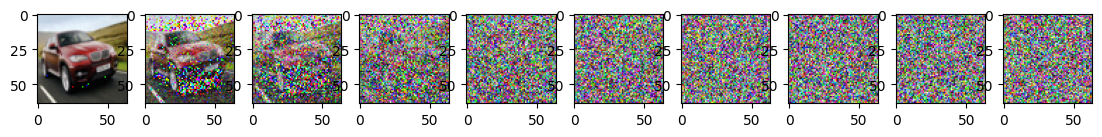

In [19]:
image = next(iter(dataloader))[0]

plt.figure(figsize=(15, 15))
# plt.axis('off')
num_images = 10
stepsize = int(T/num_images)

for idx in range(0, T, stepsize):
    t = torch.Tensor([idx]).type(torch.int64)
    plt.subplot(1, num_images+1, int(idx/stepsize)+1)
    img, noise = forward_diffusion_sample(image, t)
    show_image_tensor(img)

### Backward Process - UNET
For a great introduction to UNets, have a look at this post: https://amaarora.github.io/2020/09/13/unet.html.

Key Takeaways:
- We use a simple form of a UNet for to predict the noise in the image
- The input is a noisy image, the ouput the noise in the image
- Because the parameters are shared accross time, we need to tell the network in which timestep we are
- The Timestep is encoded by the transformer Sinusoidal Embedding
- We output one single value (mean), because the variance is fixed

In [25]:
import math
from torch import nn


class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp =  nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU()
        
    def forward(self, x, t, ):
        # First Conv
        h = self.bnorm1(self.relu(self.conv1(x)))
        # Time embedding
        time_emb = self.relu(self.time_mlp(t))
        # Extend last 2 dimensions
        time_emb = time_emb[(..., ) + (None, ) * 2]
        # Add time channel
        h = h + time_emb
        # Second Conv
        h = self.bnorm2(self.relu(self.conv2(h)))
        # Down or Upsample
        return self.transform(h)


class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        # TODO: Double check the ordering here
        return embeddings


class SimpleUnet(nn.Module):
    """
    A simplified variant of the Unet architecture.
    """
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (64, 128, 256, 512, 1024)
        up_channels = (1024, 512, 256, 128, 64)
        out_dim = 3 
        time_emb_dim = 32

        # Time embedding
        self.time_mlp = nn.Sequential(
                SinusoidalPositionEmbeddings(time_emb_dim),
                nn.Linear(time_emb_dim, time_emb_dim),
                nn.ReLU()
            )
        
        # Initial projection
        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)

        # Downsample
        self.downs = nn.ModuleList([Block(down_channels[i], down_channels[i+1], \
                                    time_emb_dim) \
                    for i in range(len(down_channels)-1)])
        # Upsample
        self.ups = nn.ModuleList([Block(up_channels[i], up_channels[i+1], \
                                        time_emb_dim, up=True) \
                    for i in range(len(up_channels)-1)])
        
        # Edit: Corrected a bug found by Jakub C (see YouTube comment)
        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, timestep):
        # Embedd time
        t = self.time_mlp(timestep)
        # Initial conv
        x = self.conv0(x)
        # Unet
        residual_inputs = []
        for down in self.downs:
            x = down(x, t)
            residual_inputs.append(x)
        for up in self.ups:
            residual_x = residual_inputs.pop()
            # Add residual x as additional channels
            x = torch.cat((x, residual_x), dim=1)           
            x = up(x, t)
        return self.output(x)

model = SimpleUnet().to(device)
print("Num params: ", sum(p.numel() for p in model.parameters()))
model

Num params:  62438883


SimpleUnet(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=32, out_features=32, bias=True)
    (2): ReLU()
  )
  (conv0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downs): ModuleList(
    (0): Block(
      (time_mlp): Linear(in_features=32, out_features=128, bias=True)
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (transform): Conv2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bnorm1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bnorm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
    )
    (1): Block(
      (time_mlp): Linear(in_features=32, out_features=256, bias=True)
      (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (transfor

In [40]:
def get_loss(model, x_0, t):
    x_noisy, noise = forward_diffusion_sample(x_0, t, device)
    noise_pred = model(x_noisy, t)
    return F.l1_loss(noise, noise_pred)

## Sampling
- Without adding @torch.no_grad() we quickly run out of memory, because pytorch tacks all the previous images for gradient calculation 
- Because we pre-calculated the noise variances for the forward pass, we also have to use them when we sequentially perform the backward process

In [16]:
# betas

In [38]:
@torch.no_grad()
def sample_timestep(x, t):
    """
    Calls the model to predict the noise in the image and returns 
    the denoised image. 
    Applies noise to this image, if we are not in the last step yet.
    """
    betas_t = get_index_from_list(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x.shape
    )
    sqrt_recip_alphas_t = get_index_from_list(sqrt_recip_alphas, t, x.shape)
    
    # Call model (current image - noise prediction)
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t
    )
    posterior_variance_t = get_index_from_list(posterior_variance, t, x.shape)
    
    if t == 0:
        # As pointed out by Luis Pereira (see YouTube comment)
        # The t's are offset from the t's in the paper
        return model_mean
    else:
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_variance_t) * noise 

@torch.no_grad()
def sample_plot_image():
    # Sample noise
    img_size = IMG_SIZE
    img = torch.randn((1, 3, img_size, img_size), device=device)
    plt.figure(figsize=(15,15))
    # plt.axis('off')
    num_images = 10
    stepsize = int(T/num_images)

    for i in range(0,T)[::-1]:
        t = torch.full((1,), i, device=device, dtype=torch.long)
        img = sample_timestep(img, t)
        # Edit: This is to maintain the natural range of the distribution
        img = torch.clamp(img, -1.0, 1.0)
        if i % stepsize == 0:
            plt.subplot(1, num_images+1, int(i/stepsize)+1)
            show_image_tensor(img.detach().cpu())
    plt.show()            

In [27]:
# model

<Figure size 500x500 with 0 Axes>

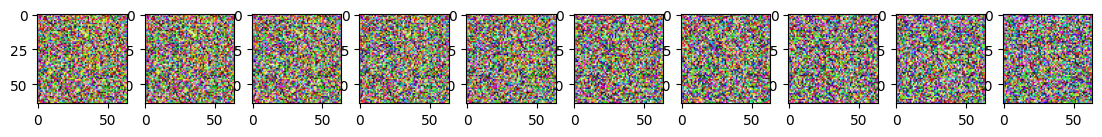

In [39]:
plt.figure(figsize=(5, 5))
sample_plot_image()
plt.show()

## Training

Epoch 0 | step: 000 | Loss: 0.81244295835495


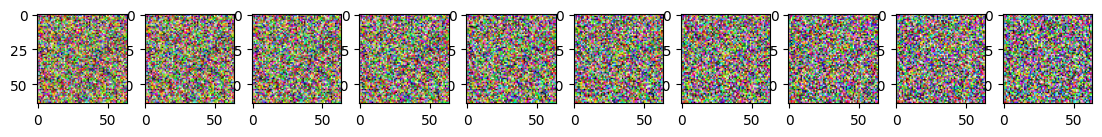

Epoch 5 | step: 000 | Loss: 0.1712772697210312


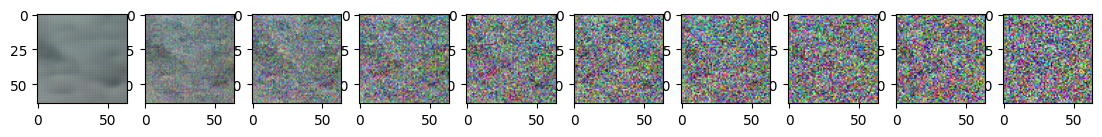

Epoch 10 | step: 000 | Loss: 0.16406498849391937


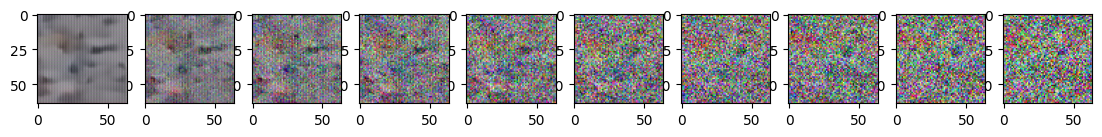

Epoch 15 | step: 000 | Loss: 0.13702549040317535


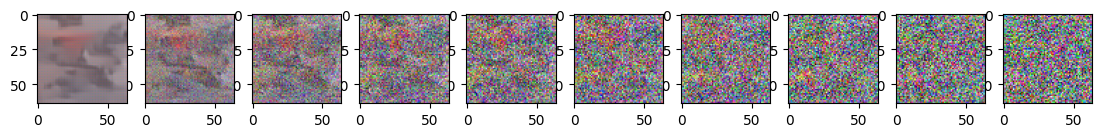

Epoch 20 | step: 000 | Loss: 0.14994952082633972


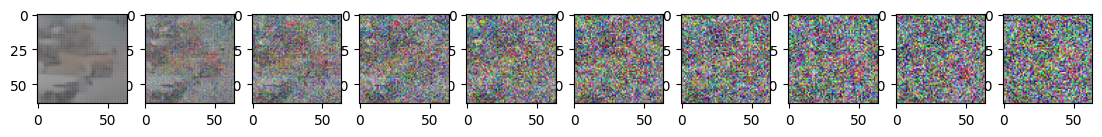

Epoch 25 | step: 000 | Loss: 0.12709560990333557


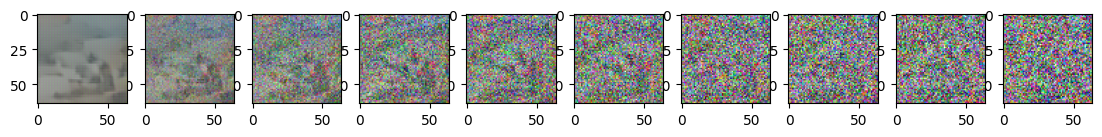

In [ ]:
from torch import optim

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 100

for epoch in range(epochs):
    for step, batch in enumerate(dataloader):
        optimizer.zero_grad()
        t = torch.randint(0, T, (BATCH_SIZE,), device=device).long()
        loss = get_loss(model, batch[0], t)
        loss.backward()
        optimizer.step()
        
        if epoch%5==0 and step==0:
            print(f"Epoch {epoch} | step: {step:03d} | Loss: {loss.item()}")
            sample_plot_image() 